In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 1.62 s (started: 2026-07-04 09:44:47 +02:00)


In [2]:
scarf.fetch_dataset("tenx_8K_pbmc_citeseq", save_path="scarf_datasets")

time: 26.6 s (started: 2026-07-04 09:44:49 +02:00)


In [3]:
reader = scarf.CrH5Reader("scarf_datasets/tenx_8K_pbmc_citeseq/data.h5")

time: 41.9 ms (started: 2026-07-04 09:45:15 +02:00)


In [4]:
reader.assayFeats

,RNA,ADT
type,Gene Expression,Antibody Capture
start,0,33538
end,33538,33555
nFeatures,33538,17


time: 12.4 ms (started: 2026-07-04 09:45:15 +02:00)


In [5]:
reader.rename_assays({"assay2": "ADT"})
reader.assayFeats

,RNA,ADT
type,Gene Expression,Antibody Capture
start,0,33538
end,33538,33555
nFeatures,33538,17


time: 10.1 ms (started: 2026-07-04 09:45:15 +02:00)


In [6]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc="scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr",
    chunk_size=(2000, 1000),
)
writer.dump(batch_size=1000)

time: 55.3 s (started: 2026-07-04 09:45:15 +02:00)


In [7]:
ds = scarf.DataStore(
    "scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr", default_assay="RNA", nthreads=4
)

Minimum cell count (501) is lower than size factor multiplier (1000)



time: 8.5 s (started: 2026-07-04 09:46:08 +02:00)


In [8]:
ds

DataStore has 7865 (7865) cells with 2 assays: RNA ADT
   Cell metadata:
            'I', 'ids', 'names', 'ADT_nFeatures', 'RNA_percentMito', 
            'RNA_percentRibo', 'ADT_nCounts', 'RNA_nFeatures', 'RNA_nCounts'
   RNA assay has 13832 (33538) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          
   ADT assay has 17 (17) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 102 ms (started: 2026-07-04 09:46:17 +02:00)


In [9]:
ds.RNA.feats.head()

,I,ids,names,dropOuts,nCells
0,False,ENSG00000243485,MIR1302-2HG,7865,0
1,False,ENSG00000237613,FAM138A,7865,0
2,False,ENSG00000186092,OR4F5,7865,0
3,False,ENSG00000238009,AL627309.1,7853,12
4,False,ENSG00000239945,AL627309.3,7865,0


time: 87.1 ms (started: 2026-07-04 09:46:17 +02:00)


In [10]:
ds.ADT.feats.head()

,I,ids,names,dropOuts,nCells
0,True,CD3,CD3_TotalSeqB,1,7864
1,True,CD4,CD4_TotalSeqB,1,7864
2,True,CD8a,CD8a_TotalSeqB,2,7863
3,True,CD14,CD14_TotalSeqB,1,7864
4,True,CD15,CD15_TotalSeqB,1,7864


time: 82.5 ms (started: 2026-07-04 09:46:17 +02:00)


154 cells flagged for filtering out using attribute RNA_nCounts



326 cells flagged for filtering out using attribute RNA_nFeatures



119 cells flagged for filtering out using attribute RNA_percentMito



21 cells flagged for filtering out using attribute RNA_percentRibo



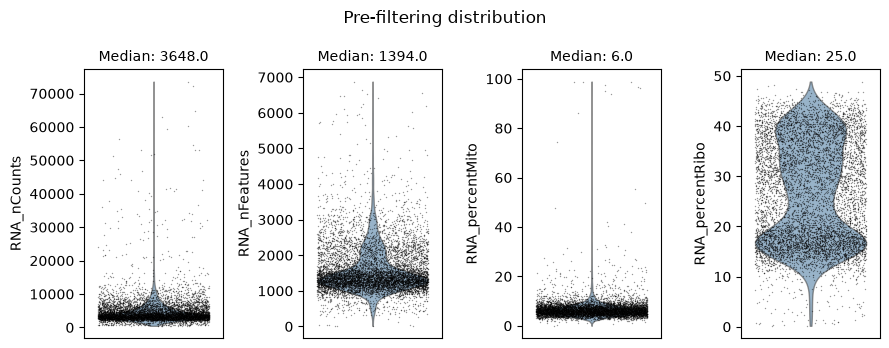

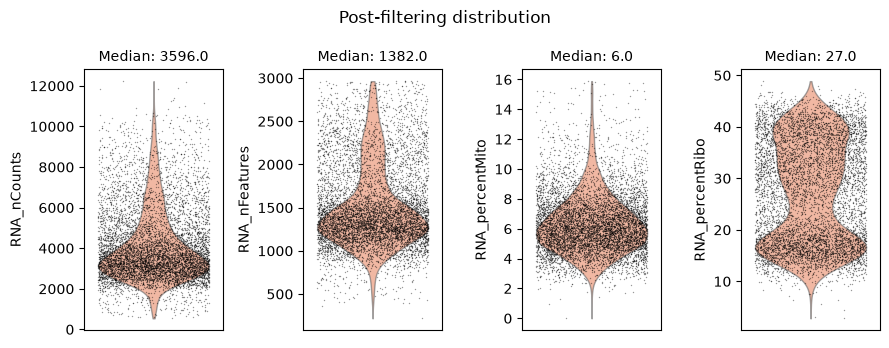

time: 3.42 s (started: 2026-07-04 09:46:17 +02:00)


In [11]:
ds.auto_filter_cells()

Calculating summary statistics



(RNA) feature stats block 1/1: read 7.0s (r2) compute 0.6s rss 994 MiB



Calculating HVGs



997 genes marked as HVGs



/home/parashar/scarf/scarf/plots.py:394: RuntimeWarning: divide by zero encountered in log2
  nzm = np.log2(nzm)
/home/parashar/scarf/scarf/plots.py:395: RuntimeWarning: divide by zero encountered in log2
  fv = np.log2(fv)


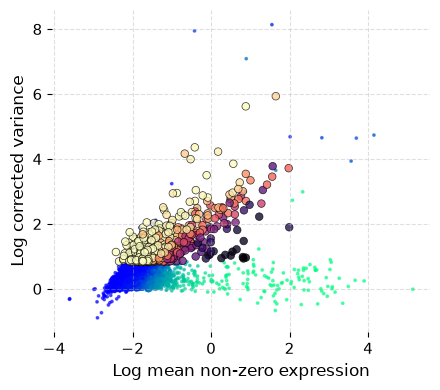

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 2.6s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.1s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 18.8s (7/7 steps, 18.7s in logged steps)



Training UMAP:   0%|                                                                                          …

time: 33 s (started: 2026-07-04 09:46:21 +02:00)


In [12]:
ds.mark_hvgs(min_cells=20, top_n=1000, min_mean=-3, max_mean=2, max_var=6)

ds.make_graph(feat_key="hvgs", k=21, dims=15, n_centroids=100)

ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)

ds.run_leiden_clustering(resolution=1)

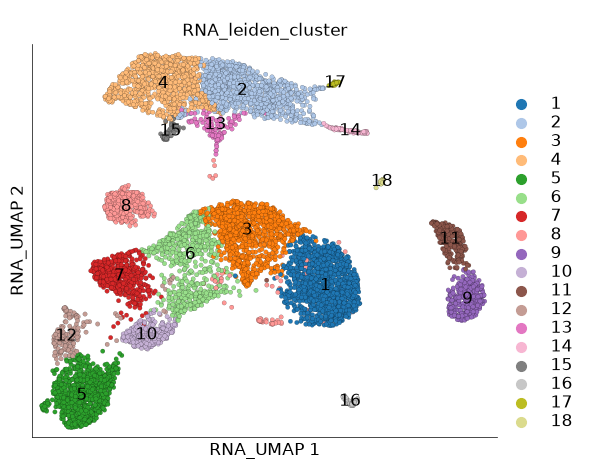

time: 288 ms (started: 2026-07-04 09:46:53 +02:00)


In [13]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_leiden_cluster", cmap="tab20")

In [14]:
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1
5,True,CD16,CD16_TotalSeqB,7864,1
6,True,CD56,CD56_TotalSeqB,7864,1
7,True,CD19,CD19_TotalSeqB,7702,163
8,True,CD25,CD25_TotalSeqB,7861,4
9,True,CD45RA,CD45RA_TotalSeqB,7864,1


time: 35.3 ms (started: 2026-07-04 09:46:53 +02:00)


In [15]:
adt_names = ds.ADT.feats.to_pandas_dataframe(["names"])["names"]
adt_names

0               CD3_TotalSeqB
1               CD4_TotalSeqB
2              CD8a_TotalSeqB
3              CD14_TotalSeqB
4              CD15_TotalSeqB
5              CD16_TotalSeqB
6              CD56_TotalSeqB
7              CD19_TotalSeqB
8              CD25_TotalSeqB
9            CD45RA_TotalSeqB
10           CD45RO_TotalSeqB
11             PD-1_TotalSeqB
12            TIGIT_TotalSeqB
13            CD127_TotalSeqB
14    IgG2a_control_TotalSeqB
15     IgG1_control_TotalSeqB
16    IgG2b_control_TotalSeqB
Name: names, dtype: object

time: 13.6 ms (started: 2026-07-04 09:46:53 +02:00)


In [16]:
is_control = adt_names.str.contains("control").values
is_control

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True])

time: 1.74 ms (started: 2026-07-04 09:46:53 +02:00)


In [17]:
ds.ADT.feats.update_key(~is_control, "I")
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1
5,True,CD16,CD16_TotalSeqB,7864,1
6,True,CD56,CD56_TotalSeqB,7864,1
7,True,CD19,CD19_TotalSeqB,7702,163
8,True,CD25,CD25_TotalSeqB,7861,4
9,True,CD45RA,CD45RA_TotalSeqB,7864,1


time: 46.1 ms (started: 2026-07-04 09:46:53 +02:00)


In [18]:
print(ds.ADT)
print(ds.ADT.normMethod.__name__)

ADTassay ADT with 14(17) features
norm_clr
time: 5.49 ms (started: 2026-07-04 09:46:53 +02:00)


In [19]:
ds.make_graph(from_assay="ADT", feat_key="I", k=21, dims=0, n_centroids=100)

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 0.1s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.0s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

ANN recall: 99.99%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 0.6s (7/7 steps, 0.5s in logged steps)



time: 574 ms (started: 2026-07-04 09:46:53 +02:00)


In [20]:
ds.run_umap(from_assay="ADT", n_epochs=250, spread=5, min_dist=1, parallel=True)

ds.run_leiden_clustering(from_assay="ADT", resolution=1)

Training UMAP:   0%|                                                                                          …

time: 3.44 s (started: 2026-07-04 09:46:54 +02:00)


In [21]:
ds.cells.head()

,I,ids,names,ADT_UMAP1,RNA_percentMito,ADT_nFeatures,ADT_UMAP2,ADT_nCounts,RNA_percentRibo,RNA_nFeatures,RNA_nCounts,RNA_leiden_cluster,RNA_UMAP2,ADT_leiden_cluster,RNA_UMAP1
0,True,AAACCCAAGATTGTGA-1,AAACCCAAGATTGTGA-1,-32.954109,8.668831,17.0,-10.241188,981.0,15.259740,2194.0,6160.0,4,32.538101,5,-14.240608
1,True,AAACCCACATCGGTTA-1,AAACCCACATCGGTTA-1,-20.347790,6.316103,17.0,-15.179193,1475.0,19.037688,2093.0,6713.0,4,30.172440,13,-13.905111
2,True,AAACCCAGTACCGCGT-1,AAACCCAGTACCGCGT-1,-26.118713,8.056090,17.0,-17.199961,7149.0,16.002200,1518.0,3637.0,2,29.267397,5,-1.165921
3,True,AAACCCAGTATCGAAA-1,AAACCCAGTATCGAAA-1,23.120407,9.003215,17.0,-27.574955,6831.0,18.729904,737.0,1244.0,5,-25.942122,3,-21.233625
4,True,AAACCCAGTCGTCATA-1,AAACCCAGTCGTCATA-1,23.614330,6.204519,17.0,-25.080168,6839.0,16.353887,1240.0,2611.0,5,-27.295912,3,-28.271555


time: 174 ms (started: 2026-07-04 09:46:56 +02:00)


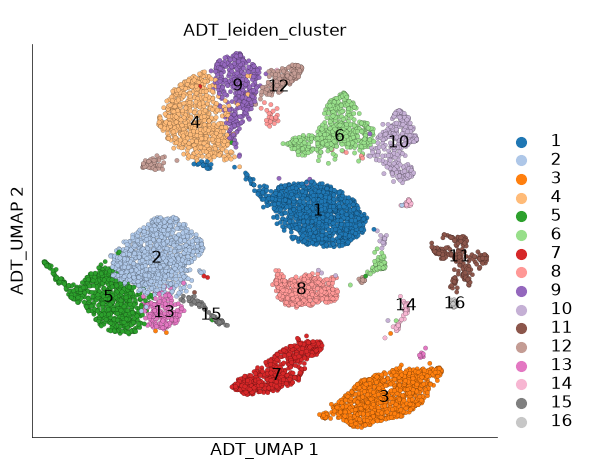

time: 296 ms (started: 2026-07-04 09:46:57 +02:00)


In [22]:
ds.plot_layout(layout_key="ADT_UMAP", color_by="ADT_leiden_cluster", cmap="tab20")

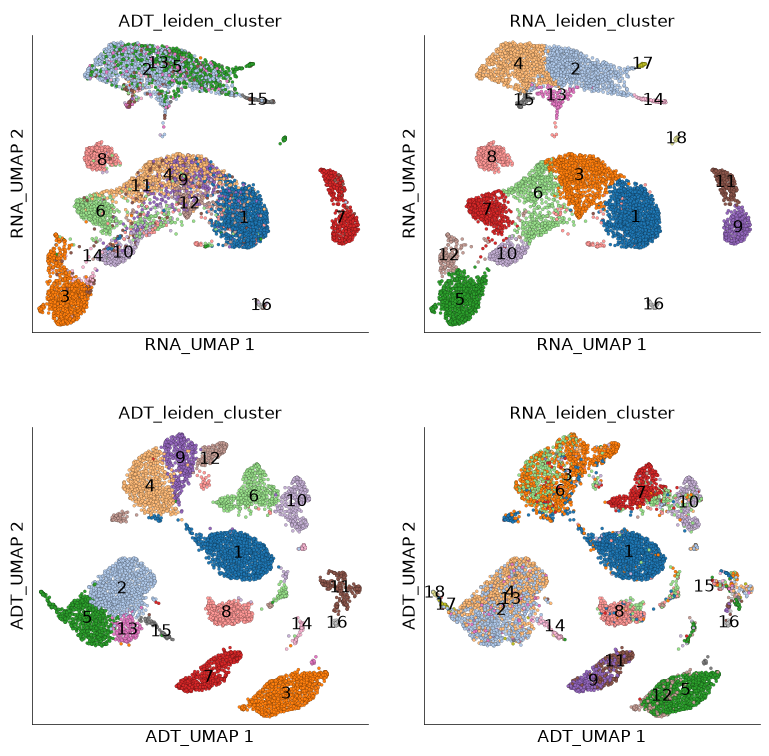

time: 779 ms (started: 2026-07-04 09:46:57 +02:00)


In [23]:
# UMAP on RNA and coloured with clusters calculated on ADT
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by=["ADT_leiden_cluster", "RNA_leiden_cluster"],
    cmap="tab20",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
    legend_onside=False,
)

In [24]:
import pandas as pd

df = pd.crosstab(
    ds.cells.fetch("RNA_leiden_cluster"), ds.cells.fetch("ADT_leiden_cluster")
)
df

col_0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
row_0,,,,,,,,,,,,,,,,
1,1036,0,0,36,3,16,0,31,28,2,17,54,0,0,0,0
2,0,360,1,0,384,3,1,0,3,0,26,1,81,17,5,0
3,33,0,0,367,1,11,1,8,262,15,22,157,0,0,0,0
4,0,566,0,2,175,2,1,0,2,2,33,1,60,7,0,0
5,0,0,732,0,0,0,0,0,1,1,32,0,0,36,1,0
6,4,0,0,277,0,97,0,49,66,64,24,7,0,2,0,0
7,0,0,1,26,0,406,0,6,2,4,14,0,0,2,0,0
8,6,3,0,0,4,24,0,345,1,6,4,4,1,0,0,0
9,0,0,0,0,0,0,315,0,0,0,8,0,0,0,0,0


time: 81 ms (started: 2026-07-04 09:46:58 +02:00)


In [25]:
(100 * df.max() / df.sum()).sort_values(ascending=False)

col_0
16    96.666667
1     94.698355
15    86.956522
3     83.466363
8     77.008929
6     70.000000
10    69.552239
9     69.129288
12    67.672414
5     60.282575
7     60.229446
2     56.998993
4     51.617440
13    50.625000
14    45.569620
11    13.095238
dtype: float64

time: 3.77 ms (started: 2026-07-04 09:46:58 +02:00)


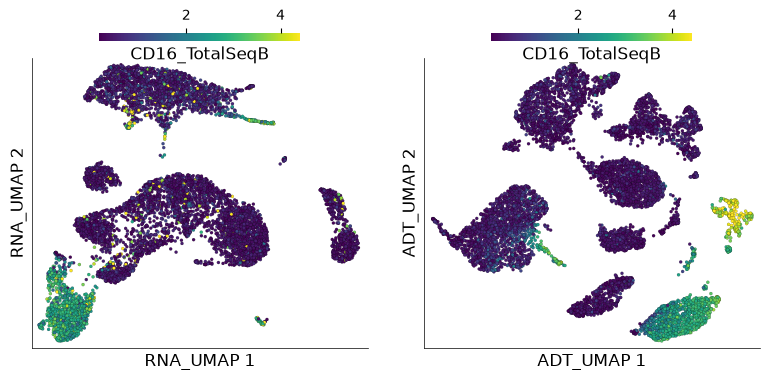

time: 584 ms (started: 2026-07-04 09:46:58 +02:00)


In [26]:
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by="CD16_TotalSeqB",
    from_assay="ADT",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
)

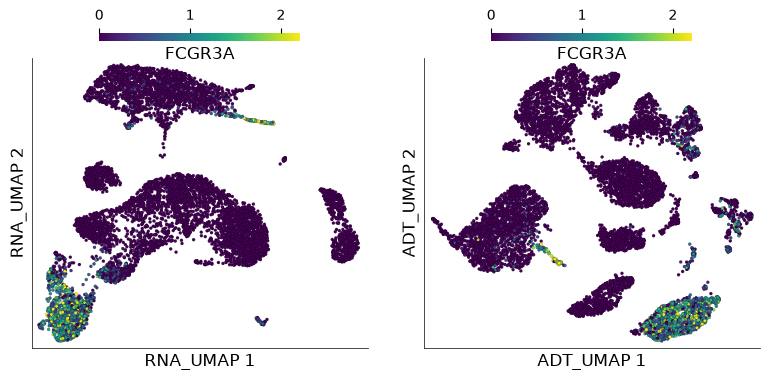

time: 2.12 s (started: 2026-07-04 09:46:58 +02:00)


In [27]:
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by="FCGR3A",
    from_assay="RNA",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
)

In [28]:
ds.integrate_assays(assays=["RNA", "ADT"], label="RNA+ADT")

time: 2.19 s (started: 2026-07-04 09:47:01 +02:00)


In [29]:
ds.run_umap(
    integrated_graph="RNA+ADT", n_epochs=500, spread=5, min_dist=0.5, parallel=True
)

ds.run_leiden_clustering(integrated_graph="RNA+ADT", resolution=1.75)

Training UMAP:   0%|                                                                                          …

time: 8.17 s (started: 2026-07-04 09:47:03 +02:00)


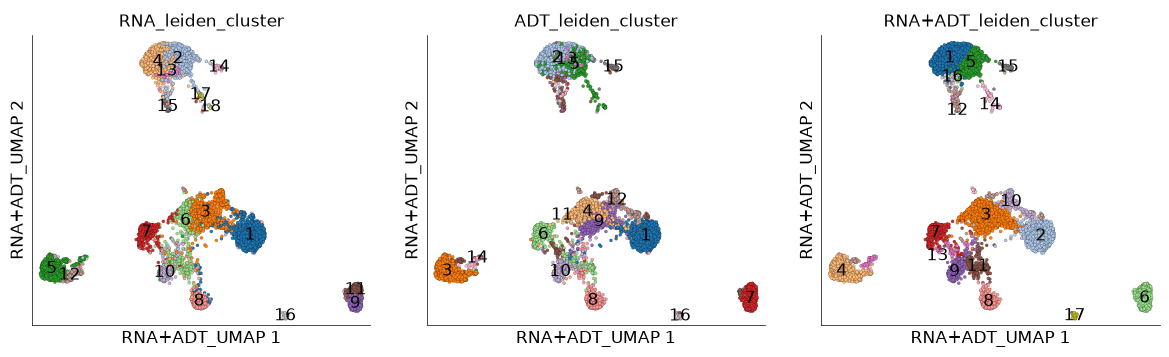

time: 668 ms (started: 2026-07-04 09:47:11 +02:00)


In [30]:
ds.plot_layout(
    layout_key=["RNA+ADT_UMAP"],
    color_by=["RNA_leiden_cluster", "ADT_leiden_cluster", "RNA+ADT_leiden_cluster"],
    cmap="tab20",
    legend_onside=False,
    point_size=5,
    width=4,
    height=4,
    n_columns=3,
)

In [31]:
ds.cells.columns

['I',
 'ids',
 'names',
 'RNA_percentMito',
 'RNA+ADT_UMAP1',
 'ADT_nFeatures',
 'ADT_UMAP1',
 'ADT_UMAP2',
 'ADT_nCounts',
 'RNA_nFeatures',
 'RNA+ADT_leiden_cluster',
 'RNA_nCounts',
 'RNA_leiden_cluster',
 'RNA+ADT_UMAP2',
 'RNA_percentRibo',
 'RNA_UMAP2',
 'ADT_leiden_cluster',
 'RNA_UMAP1']

time: 19.4 ms (started: 2026-07-04 09:47:12 +02:00)


In [32]:
ds.integrate_assays(assays=["RNA", "ADT"], label="RNA+ADT_wnn", method="wnn")

ds.run_umap(
    integrated_graph="RNA+ADT_wnn", n_epochs=500, spread=5, min_dist=0.5, parallel=True
)

ds.run_leiden_clustering(integrated_graph="RNA+ADT_wnn", resolution=1.75)

make_graph step 1/7: normalize expression matrix (reusing cached)



Using existing normalized data with cell key I and feat key I__hvgs



make_graph step 1/7: normalize expression matrix finished in 0.1s (reusing cached)



make_graph step 2/7: normalization statistics (reusing cached)



make_graph step 2/7: normalization statistics finished in 0.0s (reusing cached)



...

make_graph finished in 0.2s (7/7 steps, 0.1s in logged steps)



No dimension reduction was user for ADT data. Memory consumption will be high.



/home/parashar/scarf/scarf/knn_utils.py:521: RuntimeWarning: overflow encountered in exp
  wr = np.exp(sr) / (np.exp(sr) + np.exp(sp))
/home/parashar/scarf/scarf/knn_utils.py:522: RuntimeWarning: overflow encountered in exp
  wp = np.exp(sp) / (np.exp(sr) + np.exp(sp))
/home/parashar/scarf/scarf/knn_utils.py:522: RuntimeWarning: invalid value encountered in divide
  wp = np.exp(sp) / (np.exp(sr) + np.exp(sp))


Training UMAP:   0%|                                                                                          …

time: 7.99 s (started: 2026-07-04 09:47:12 +02:00)


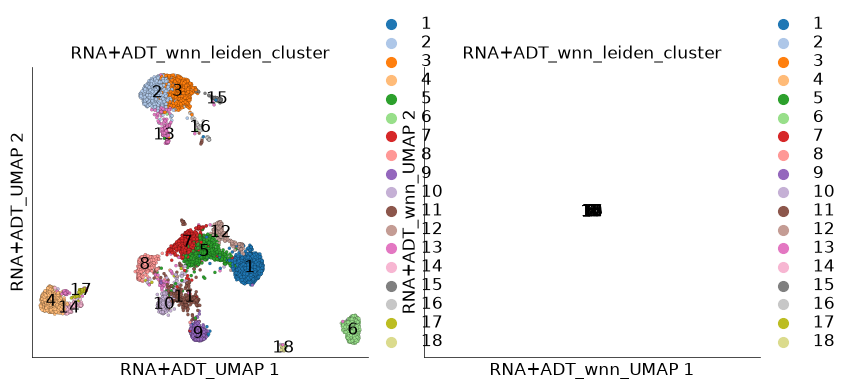

time: 970 ms (started: 2026-07-04 09:47:20 +02:00)


In [33]:
ds.plot_layout(
    layout_key=["RNA+ADT_UMAP", "RNA+ADT_wnn_UMAP"],
    color_by="RNA+ADT_wnn_leiden_cluster",
    cmap="tab20",
    point_size=5,
    width=4,
    height=4,
    n_columns=2,
)